In [ ]:
from google.colab import files
uploaded = files.upload()

Saving IMDb Movies India.csv to IMDb Movies India.csv


In [ ]:
import os
print(os.listdir())

['.config', 'IMDb Movies India.csv', 'sample_data']


Original Shape: (15509, 10)
R2 Score: 0.05924161330402011


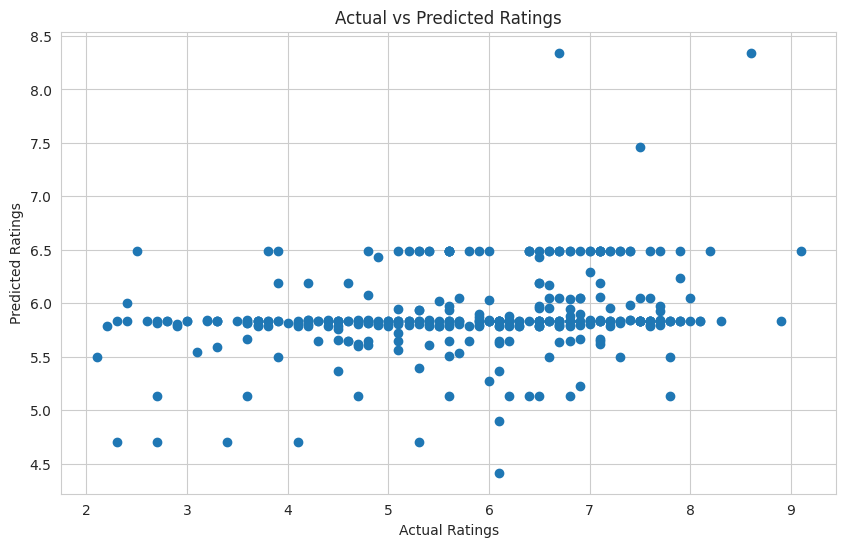

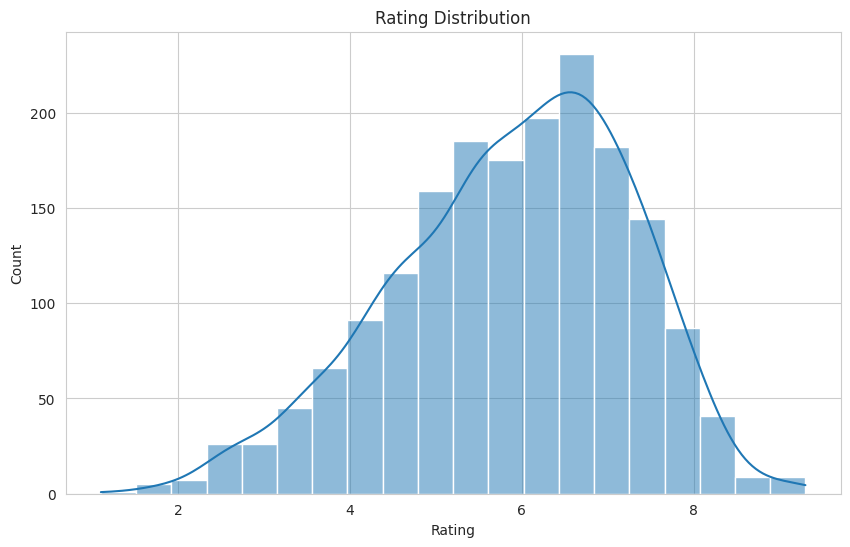

In [ ]:
# ==========================================
# 🎬 Movie Rating Prediction (OPTIMIZED)
# ==========================================

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

# Load dataset
data = pd.read_csv("IMDb Movies India.csv", encoding='latin1')

print("Original Shape:", data.shape)

# -------------------------------
# ✅ Reduce dataset size (IMPORTANT)
# -------------------------------
data = data.sample(5000, random_state=42)  # take only 5000 rows

# Drop missing values
data = data.dropna()

# -------------------------------
# ✅ Keep only important columns
# -------------------------------
data = data[['Genre', 'Director', 'Actor 1', 'Rating']]

# -------------------------------
# ✅ Reduce categories (VERY IMPORTANT)
# -------------------------------
top_directors = data['Director'].value_counts().head(10).index
data['Director'] = data['Director'].apply(lambda x: x if x in top_directors else 'Other')

top_actors = data['Actor 1'].value_counts().head(10).index
data['Actor 1'] = data['Actor 1'].apply(lambda x: x if x in top_actors else 'Other')

# -------------------------------
# ✅ Convert text to numbers
# -------------------------------
data = pd.get_dummies(data)

# -------------------------------
# Split data
# -------------------------------
from sklearn.model_selection import train_test_split

X = data.drop('Rating', axis=1)
y = data['Rating']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -------------------------------
# 🔥 Fast Model (Random Forest - optimized)
# -------------------------------
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=50,      # reduced trees
    max_depth=10,         # limit depth
    random_state=42
)

model.fit(X_train, y_train)

# Predictions
pred = model.predict(X_test)

# Evaluation
from sklearn.metrics import r2_score

print("R2 Score:", r2_score(y_test, pred))

# -------------------------------
# 📊 Graphs
# -------------------------------

# Actual vs Predicted
plt.scatter(y_test, pred)
plt.xlabel("Actual Ratings")
plt.ylabel("Predicted Ratings")
plt.title("Actual vs Predicted Ratings")
plt.show()

# Rating Distribution
sns.histplot(y, bins=20, kde=True)
plt.title("Rating Distribution")
plt.show()


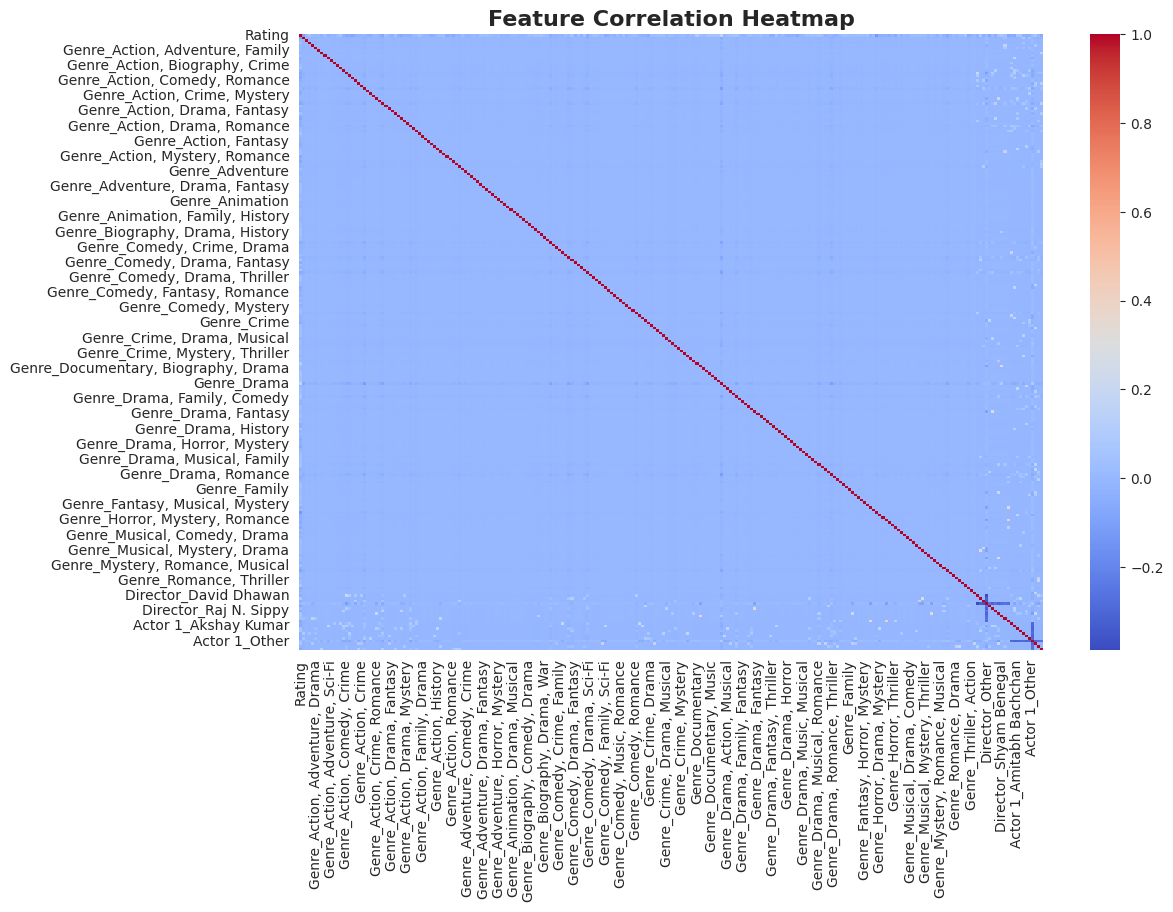

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = data.corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap='coolwarm', annot=False)
plt.title("Feature Correlation Heatmap", fontsize=16, fontweight='bold')
plt.show()

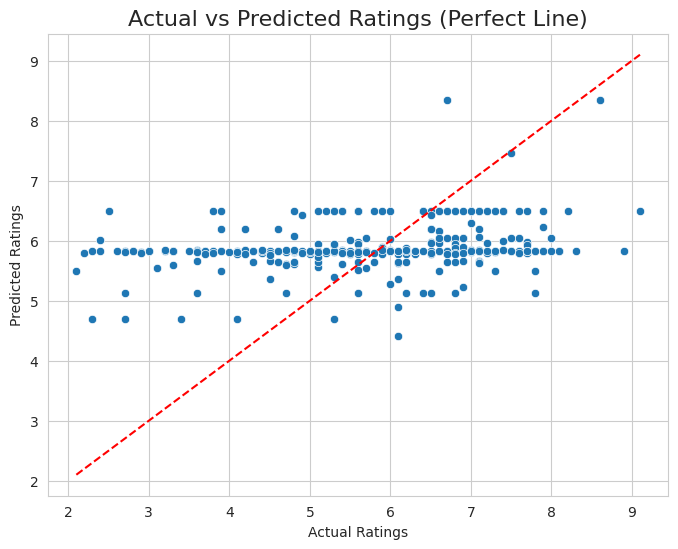

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=pred)

# Perfect prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linestyle='--')

plt.xlabel("Actual Ratings")
plt.ylabel("Predicted Ratings")
plt.title("Actual vs Predicted Ratings (Perfect Line)", fontsize=16)
plt.show()

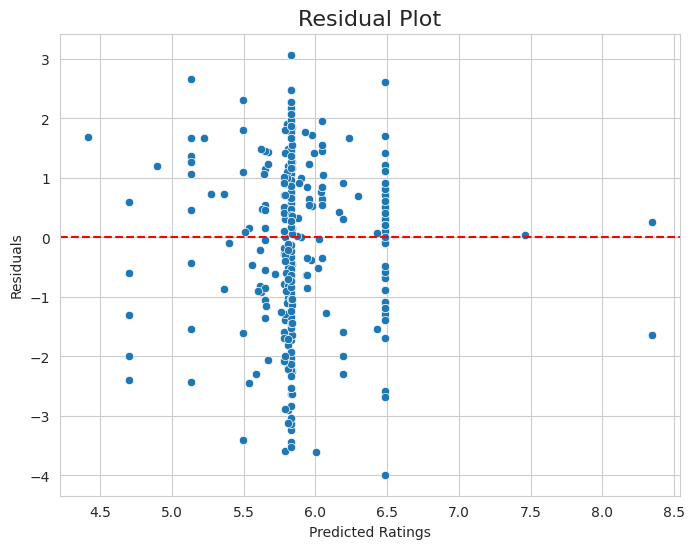

In [ ]:
residuals = y_test - pred

plt.figure(figsize=(8,6))
sns.scatterplot(x=pred, y=residuals)

plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Ratings")
plt.ylabel("Residuals")
plt.title("Residual Plot", fontsize=16)
plt.show()

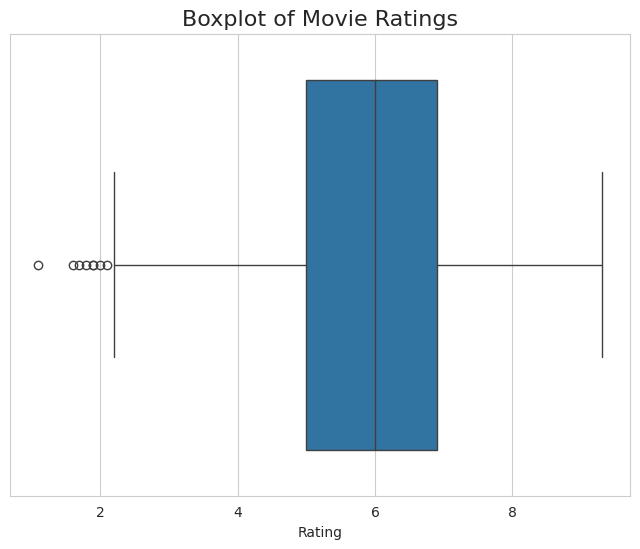

In [ ]:
plt.figure(figsize=(8,6))
sns.boxplot(x=y)

plt.title("Boxplot of Movie Ratings", fontsize=16)
plt.show()

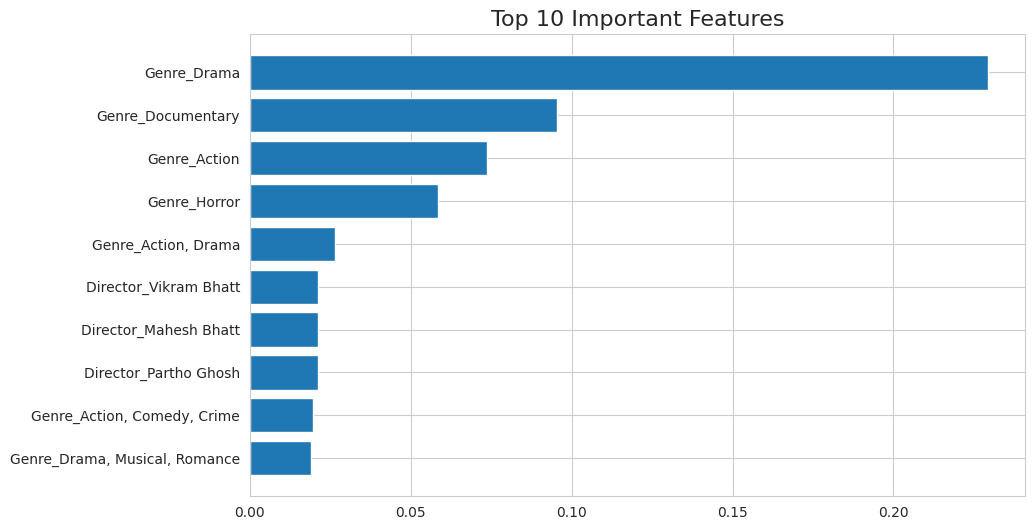

In [ ]:
import numpy as np

importances = model.feature_importances_
indices = np.argsort(importances)[-10:]

plt.figure(figsize=(10,6))
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), X.columns[indices])
plt.title("Top 10 Important Features", fontsize=16)
plt.show()

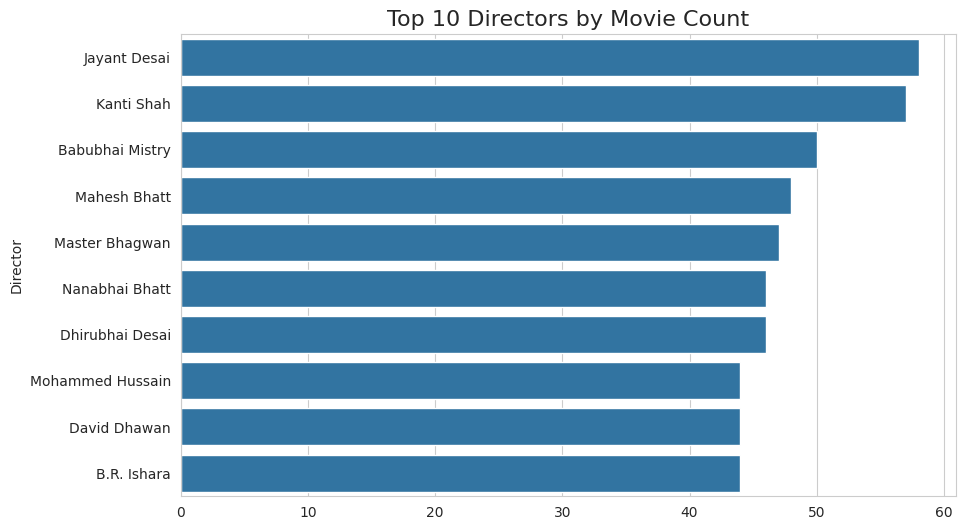

In [ ]:
original = pd.read_csv("IMDb Movies India.csv", encoding='latin1')

top_directors = original['Director'].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_directors.values, y=top_directors.index)
plt.title("Top 10 Directors by Movie Count", fontsize=16)
plt.show()